# Clinic No-Show — Public Evidence Notebook

**Case study:** operational prediction of outpatient appointment no-shows for a
private clinic (synthetic).

> ⚠️ **Synthetic data disclaimer.** Every row in `no_show_dataset.csv` is generated
> data — no real patients, clinicians, or clinical outcomes are represented, and
> there is no PHI/PII of any kind. Results are for **methodology demonstration**
> only (data generation → cleaning → EDA → leakage-aware feature engineering →
> temporal modeling), not a clinical tool and not a causal or predictive claim
> about real populations.

**Reproducibility contract**

| | |
|---|---|
| Dataset | `no_show_dataset.csv` (this folder) — 12,000 cleaned appointments, 22 columns |
| Seed | `42` |
| Target | `no_show_flag`, modeling population `cancellation_flag == 0` |
| Split | Temporal train / validation / test by `appointment_date` (~65/15/20) |
| Selected model | Logistic Regression |
| Decision threshold | Selected on **validation only** (~0.4114), reported once on untouched **test** |

This notebook is fully self-contained: it only reads `no_show_dataset.csv` (and, in
the closing check, `portfolio_manifest.json`) from this same folder, and only uses
public libraries (pandas / numpy / scikit-learn / matplotlib). It does not import
any Paradigm application code or private pipeline modules — it *reproduces* their
documented methodology from public data alone.

Full scenario, data model and data dictionary: see `README.md` and
`data_dictionary.xlsx` in this folder.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.25})

SEED = 42
TARGET = "no_show_flag"
np.random.seed(SEED)

## 1. Load & data quality

The dataset here is already the **cleaned** analytical table (equivalent to
`processed/appointments_cleaned.csv` in the source repo) — deduplicated, with
normalized categorical casing and imputed `"unknown"` labels. We just confirm
that contract holds before modeling.

In [2]:
DATA_PATH = Path("no_show_dataset.csv")
df = pd.read_csv(DATA_PATH, parse_dates=["appointment_date", "booking_date"])
print(f"Loaded {len(df):,} rows x {df.shape[1]} columns from '{DATA_PATH.name}'")
df.head(3)

Loaded 12,000 rows x 22 columns from 'no_show_dataset.csv'


,appointment_id,patient_id,professional_id,specialty,appointment_date,booking_date,appointment_hour,day_of_week,booking_channel,insurance_type,patient_age,patient_gender,city_zone,previous_appointments,previous_no_shows,lead_time_days,waiting_time_minutes,scheduled_duration_minutes,actual_duration_minutes,cancellation_flag,no_show_flag,rescheduled_flag
0,1,210,4,dermatology,2023-01-02,2022-12-18,11,0,reception,prepaid,61,female,west,0,0,15,NaN,15,NaN,1,0,1
1,2,2591,2,neurology,2023-01-02,2022-12-20,8,0,reception,self_pay,10,female,east,0,0,13,NaN,45,NaN,0,1,0
2,3,2044,3,pediatrics,2023-01-02,2022-12-15,11,0,web,private,16,female,north,0,0,18,NaN,30,NaN,1,0,0


In [3]:
quality = pd.Series({
    "rows": len(df),
    "columns": df.shape[1],
    "duplicate_appointment_id_rows": int(df["appointment_id"].duplicated().sum()),
    "outcome_conflicts_cancel_and_noshow": int(
        ((df["cancellation_flag"] == 1) & (df["no_show_flag"] == 1)).sum()
    ),
    "date_order_violations (booking > appointment)": int(
        (df["booking_date"] > df["appointment_date"]).sum()
    ),
    "date_range_start": df["appointment_date"].min().date().isoformat(),
    "date_range_end": df["appointment_date"].max().date().isoformat(),
})
print(quality.to_string())

nulls = df.isna().sum()
nulls = nulls[nulls > 0]
print("\nColumns with nulls (expected: post-event fields only, null when cancelled/no-show):")
print(nulls.to_string())

rows                                                  12000
columns                                                  22
duplicate_appointment_id_rows                             0
outcome_conflicts_cancel_and_noshow                       0
date_order_violations (booking > appointment)             0
date_range_start                                 2023-01-02
date_range_end                                   2025-06-30

Columns with nulls (expected: post-event fields only, null when cancelled/no-show):
waiting_time_minutes       3020
actual_duration_minutes    3020


## 2. Brief EDA

Appointment outcomes are mutually exclusive: **cancelled**, **no-show**, or
**attended**. `no_show_flag` is only defined for non-cancelled appointments — that
is the modeling population (`cancellation_flag == 0`, the "eligible" universe).

cancelled    1504
no_show      1516
attended     8980

Eligible no-show rate: 14.44%  (n=10,496)


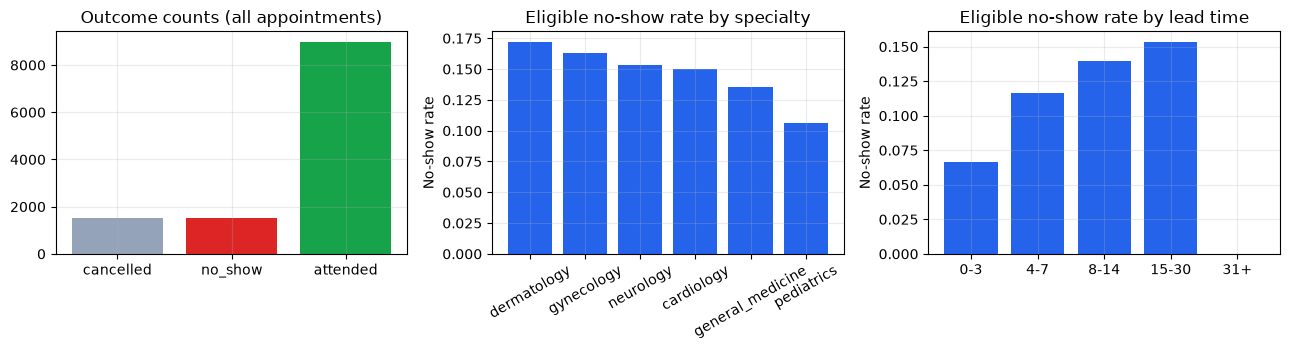

In [4]:
eligible = df[df["cancellation_flag"] == 0].copy()

outcome_counts = pd.Series({
    "cancelled": int((df["cancellation_flag"] == 1).sum()),
    "no_show": int(((df["cancellation_flag"] == 0) & (df["no_show_flag"] == 1)).sum()),
    "attended": int(((df["cancellation_flag"] == 0) & (df["no_show_flag"] == 0)).sum()),
})
print(outcome_counts.to_string())
print(f"\nEligible no-show rate: {eligible['no_show_flag'].mean():.2%}  (n={len(eligible):,})")

lead_bucket = pd.cut(
    eligible["lead_time_days"], bins=[-0.1, 3, 7, 14, 30, 120],
    labels=["0-3", "4-7", "8-14", "15-30", "31+"],
)
by_specialty = eligible.groupby("specialty")["no_show_flag"].mean().sort_values(ascending=False)
by_lead = eligible.groupby(lead_bucket, observed=True)["no_show_flag"].mean()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].bar(outcome_counts.index, outcome_counts.values, color=["#94a3b8", "#dc2626", "#16a34a"])
axes[0].set_title("Outcome counts (all appointments)")

axes[1].bar(by_specialty.index, by_specialty.values, color="#2563eb")
axes[1].set_title("Eligible no-show rate by specialty")
axes[1].tick_params(axis="x", rotation=30)

axes[2].bar(by_lead.index.astype(str), by_lead.values, color="#2563eb")
axes[2].set_title("Eligible no-show rate by lead time")

for ax in axes[1:]:
    ax.set_ylabel("No-show rate")
fig.tight_layout()
plt.show()

## 3. Feature engineering (leakage-aware)

Predictors are restricted to information knowable **at booking / pre-visit
decision time**. The following are excluded as predictors:

- Identifiers (`appointment_id`, `patient_id`, `professional_id`)
- Post-event / descriptive fields — **leakage risk**: `waiting_time_minutes`,
  `actual_duration_minutes` (only observed for attended visits)
- Competing outcome: `cancellation_flag` (used only to define the eligible
  population, never as a predictor)
- The target itself: `no_show_flag`

Engineered features mirror the source pipeline (`features.py`): lead-time /
appointment-hour / age buckets, booking history rate, weekday flags, and a
phone-channel flag.

In [5]:
FEATURE_NUMERIC = [
    "lead_time_days", "appointment_hour", "day_of_week", "month",
    "previous_appointments", "previous_no_shows", "historical_no_show_rate",
    "is_first_appointment", "is_weekend", "is_week_edge", "high_risk_channel",
    "scheduled_duration_minutes", "rescheduled_flag", "patient_age",
]
FEATURE_CATEGORICAL = [
    "specialty", "booking_channel", "insurance_type", "city_zone",
    "patient_gender", "lead_time_bucket", "hour_band", "age_group_feat",
]
FEATURE_COLUMNS = FEATURE_NUMERIC + FEATURE_CATEGORICAL


def build_feature_frame(cleaned: pd.DataFrame) -> pd.DataFrame:
    """Eligible modeling rows with engineered pre-appointment features
    (mirrors case_studies/clinic_no_show/features.py::build_feature_frame)."""
    out = cleaned[cleaned["cancellation_flag"] == 0].copy().reset_index(drop=True)

    out["lead_time_bucket"] = pd.cut(
        out["lead_time_days"], bins=[-0.1, 3, 7, 14, 30, 120],
        labels=["0_3", "4_7", "8_14", "15_30", "31_plus"],
    ).astype(str)
    out["hour_band"] = pd.cut(
        out["appointment_hour"], bins=[7, 10, 13, 16, 19], right=False,
        labels=["early", "mid_morning", "afternoon", "late"],
    ).astype(str)
    out["age_group_feat"] = pd.cut(
        out["patient_age"], bins=[-0.1, 17, 34, 49, 64, 95],
        labels=["0_17", "18_34", "35_49", "50_64", "65_plus"],
    ).astype(str)

    prev = out["previous_appointments"].astype(float)
    prev_ns = out["previous_no_shows"].astype(float)
    out["historical_no_show_rate"] = np.where(prev > 0, prev_ns / prev, 0.0)
    out["is_first_appointment"] = (out["previous_appointments"] == 0).astype(int)
    out["month"] = out["appointment_date"].dt.month.astype(int)
    out["is_weekend"] = (out["day_of_week"] >= 5).astype(int)
    out["is_week_edge"] = out["day_of_week"].isin([0, 4]).astype(int)
    out["high_risk_channel"] = (out["booking_channel"] == "phone").astype(int)

    keep = ["appointment_id", "appointment_date", TARGET, *FEATURE_COLUMNS]
    return out[keep]


feature_df = build_feature_frame(df)
print(f"Eligible modeling rows: {len(feature_df):,}  (positive rate {feature_df[TARGET].mean():.2%})")
feature_df.head(3)

Eligible modeling rows: 10,496  (positive rate 14.44%)


,appointment_id,appointment_date,no_show_flag,lead_time_days,appointment_hour,day_of_week,month,previous_appointments,previous_no_shows,historical_no_show_rate,is_first_appointment,is_weekend,is_week_edge,high_risk_channel,scheduled_duration_minutes,rescheduled_flag,patient_age,specialty,booking_channel,insurance_type,city_zone,patient_gender,lead_time_bucket,hour_band,age_group_feat
0,2,2023-01-02,1,13,8,0,1,0,0,0.0,1,0,1,0,45,0,10,neurology,reception,self_pay,east,female,8_14,early,0_17
1,4,2023-01-02,0,12,14,0,1,0,0,0.0,1,0,1,1,60,1,23,dermatology,phone,social_security,center,male,8_14,afternoon,18_34
2,5,2023-01-02,0,19,16,0,1,0,0,0.0,1,0,1,0,30,0,83,cardiology,web,prepaid,north,male,15_30,late,65_plus


## 4. Temporal train / validation / test split

Chronological split by `appointment_date` — train precedes validation, which
precedes the final test window (no shuffling, no random holdout, no cross-fold
leakage across time). Cutoffs are date-aligned so a calendar day is never split
across folds. Target shares: train ≈65%, validation ≈15%, test ≈20%.

In [6]:
TEST_FRACTION = 0.20
VAL_FRACTION = 0.15


def _cutoff_date_for_tail(frame: pd.DataFrame, n_tail: int) -> pd.Timestamp:
    n = len(frame)
    n_tail = max(1, min(n_tail, n - 1))
    idx = n - n_tail
    return pd.Timestamp(frame.loc[idx, "appointment_date"])


def temporal_three_way_split(frame: pd.DataFrame, test_fraction=TEST_FRACTION, val_fraction=VAL_FRACTION):
    """Mirrors case_studies/clinic_no_show/features.py::temporal_three_way_split."""
    d = frame.sort_values(["appointment_date", "appointment_id"]).reset_index(drop=True)
    n = len(d)
    n_test = max(1, int(round(n * test_fraction)))
    n_val = max(1, int(round(n * val_fraction)))
    if n_test + n_val >= n:
        n_val = max(1, n // 5)
        n_test = max(1, n // 5)

    test_cut = _cutoff_date_for_tail(d, n_test)
    pre_test = d[d["appointment_date"] < test_cut].copy().reset_index(drop=True)
    test_ = d[d["appointment_date"] >= test_cut].copy()

    val_cut = _cutoff_date_for_tail(pre_test, min(n_val, len(pre_test) - 1))
    train_ = pre_test[pre_test["appointment_date"] < val_cut].copy()
    val_ = pre_test[pre_test["appointment_date"] >= val_cut].copy()

    if len(train_) == 0 or len(val_) == 0 or len(test_) == 0:
        # Positional fallback (not triggered on this dataset; kept for fidelity
        # with the source pipeline's edge-case handling).
        n_test = max(1, int(round(n * test_fraction)))
        n_val = max(1, int(round(n * val_fraction)))
        train_ = d.iloc[: n - n_test - n_val].copy()
        val_ = d.iloc[n - n_test - n_val : n - n_test].copy()
        test_ = d.iloc[n - n_test :].copy()
        val_cut = val_["appointment_date"].min()
        test_cut = test_["appointment_date"].min()

    meta = {
        "validation_cutoff_date": pd.Timestamp(val_cut).strftime("%Y-%m-%d"),
        "test_cutoff_date": pd.Timestamp(test_cut).strftime("%Y-%m-%d"),
        "train_rows": int(len(train_)),
        "validation_rows": int(len(val_)),
        "test_rows": int(len(test_)),
        "train_start": train_["appointment_date"].min().strftime("%Y-%m-%d"),
        "train_end": train_["appointment_date"].max().strftime("%Y-%m-%d"),
        "validation_start": val_["appointment_date"].min().strftime("%Y-%m-%d"),
        "validation_end": val_["appointment_date"].max().strftime("%Y-%m-%d"),
        "test_start": test_["appointment_date"].min().strftime("%Y-%m-%d"),
        "test_end": test_["appointment_date"].max().strftime("%Y-%m-%d"),
        "train_positive_rate": float(train_[TARGET].mean()),
        "validation_positive_rate": float(val_[TARGET].mean()),
        "test_positive_rate": float(test_[TARGET].mean()),
    }
    return train_, val_, test_, meta


train, val, test, split_meta = temporal_three_way_split(feature_df)
pd.Series(split_meta)

validation_cutoff_date      2024-08-16
test_cutoff_date            2024-12-31
train_rows                        6809
validation_rows                   1580
test_rows                         2107
train_start                 2023-01-02
train_end                   2024-08-15
validation_start            2024-08-16
validation_end              2024-12-30
test_start                  2024-12-31
test_end                    2025-06-30
train_positive_rate           0.147746
validation_positive_rate       0.14557
test_positive_rate             0.13289
dtype: object

## 5. Training

Preprocessing (`StandardScaler` for numeric, one-hot encoding for categorical
features) and three candidate model families are **fit on train only**:
Logistic Regression (`class_weight="balanced"`), Random Forest, and
HistGradientBoosting — plus a majority-class baseline for reference.

In [7]:
def make_preprocessor() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), FEATURE_NUMERIC),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), FEATURE_CATEGORICAL),
        ],
        remainder="drop",
    )


def build_models(seed: int = SEED) -> dict[str, Pipeline]:
    return {
        "logistic_regression": Pipeline([
            ("pre", make_preprocessor()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=seed)),
        ]),
        "random_forest": Pipeline([
            ("pre", make_preprocessor()),
            ("clf", RandomForestClassifier(
                n_estimators=200, min_samples_leaf=5,
                class_weight="balanced_subsample", random_state=seed, n_jobs=-1,
            )),
        ]),
        "hist_gradient_boosting": Pipeline([
            ("pre", make_preprocessor()),
            ("clf", HistGradientBoostingClassifier(
                max_depth=4, learning_rate=0.08, max_iter=200, random_state=seed,
            )),
        ]),
    }


X_train, y_train = train[FEATURE_COLUMNS], train[TARGET].to_numpy()
X_val, y_val = val[FEATURE_COLUMNS], val[TARGET].to_numpy()
X_test, y_test = test[FEATURE_COLUMNS], test[TARGET].to_numpy()

fitted, val_probas = {}, {}
for name, model in build_models().items():
    model.fit(X_train, y_train)
    fitted[name] = model
    val_probas[name] = model.predict_proba(X_val)[:, 1]

print("Fitted on train:", list(fitted))

Fitted on train: ['logistic_regression', 'random_forest', 'hist_gradient_boosting']


## 6. Model selection & threshold (validation only)

Model family is chosen by validation **average precision**, with a preference
for Logistic Regression whenever it is within 0.02 AP of the best model
(interpretability over a marginal ranking gain). The operational threshold is
then swept **on validation only** — max F1, with a small bonus if recall ≥ 0.40
— and frozen before ever touching the test fold.

In [8]:
def ranking_metrics(y_true, proba) -> dict:
    return {
        "roc_auc": float(roc_auc_score(y_true, proba)),
        "average_precision": float(average_precision_score(y_true, proba)),
        "brier_score": float(brier_score_loss(y_true, proba)),
    }


val_comparison = pd.DataFrame(
    {name: ranking_metrics(y_val, p) for name, p in val_probas.items()}
).T
val_comparison

,roc_auc,average_precision,brier_score
logistic_regression,0.600522,0.190866,0.246349
random_forest,0.619987,0.193085,0.158730
hist_gradient_boosting,0.605187,0.182155,0.128301


In [9]:
def metrics_at_threshold(y_true, proba, threshold: float) -> dict:
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "threshold": float(threshold),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
        "predicted_positive_rate": float(pred.mean()),
    }


def select_threshold(y_true, proba) -> dict:
    """VALIDATION ONLY: max F1, +0.02 bonus if recall >= 0.40 (mirrors model.py)."""
    candidates = np.unique(np.quantile(proba, np.linspace(0.05, 0.95, 37)))
    rows = []
    for t in candidates:
        m = metrics_at_threshold(y_true, proba, float(t))
        score = m["f1"] + (0.02 if m["recall"] >= 0.40 else 0.0)
        rows.append({**m, "selection_score": score})
    return max(rows, key=lambda r: r["selection_score"])


val_ap = {name: val_comparison.loc[name, "average_precision"] for name in fitted}
best_name, best_ap = max(val_ap.items(), key=lambda t: t[1])
log_ap = val_ap["logistic_regression"]
selected = "logistic_regression" if (best_ap - log_ap) <= 0.02 else best_name

thr_selection = select_threshold(y_val, val_probas[selected])
selected_threshold = thr_selection["threshold"]

print(f"Validation AP by model: { {k: round(v, 4) for k, v in val_ap.items()} }")
print(f"Selected model:          {selected}")
print(f"Selected threshold:      {selected_threshold:.4f}  (from validation only)")

Validation AP by model: {'logistic_regression': np.float64(0.1909), 'random_forest': np.float64(0.1931), 'hist_gradient_boosting': np.float64(0.1822)}
Selected model:          logistic_regression
Selected threshold:      0.4114  (from validation only)


## 7. Final evaluation (untouched test)

The frozen model + threshold are scored **once** on the final temporal test
fold. No further tuning happens after this point.

In [10]:
val_proba_selected = val_probas[selected]
test_proba = fitted[selected].predict_proba(X_test)[:, 1]

val_ranking = ranking_metrics(y_val, val_proba_selected)
test_ranking = ranking_metrics(y_test, test_proba)
val_at_thr = metrics_at_threshold(y_val, val_proba_selected, selected_threshold)
test_at_thr = metrics_at_threshold(y_test, test_proba, selected_threshold)
test_at_05 = metrics_at_threshold(y_test, test_proba, 0.5)

print("Validation ranking:      ", {k: round(v, 4) for k, v in val_ranking.items()})
print("Final TEST ranking:      ", {k: round(v, 4) for k, v in test_ranking.items()})
print("Final TEST @ threshold:  ", {k: (round(v, 4) if not isinstance(v, dict) else v) for k, v in test_at_thr.items()})

Validation ranking:       {'roc_auc': 0.6005, 'average_precision': 0.1909, 'brier_score': 0.2463}
Final TEST ranking:       {'roc_auc': 0.6052, 'average_precision': 0.1776, 'brier_score': 0.2657}
Final TEST @ threshold:   {'threshold': 0.4114, 'precision': 0.153, 'recall': 0.8643, 'f1': 0.2599, 'confusion_matrix': {'tn': 487, 'fp': 1340, 'fn': 38, 'tp': 242}, 'predicted_positive_rate': 0.7508}


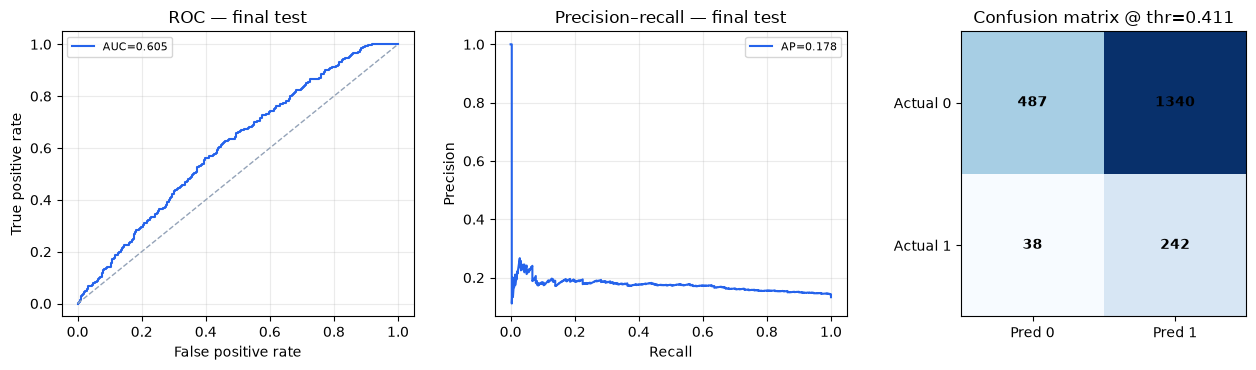

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

fpr, tpr, _ = roc_curve(y_test, test_proba)
axes[0].plot(fpr, tpr, color="#2563eb", label=f"AUC={test_ranking['roc_auc']:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="#94a3b8", linewidth=1)
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC — final test"); axes[0].legend(fontsize=8)

prec, rec, _ = precision_recall_curve(y_test, test_proba)
axes[1].plot(rec, prec, color="#2563eb", label=f"AP={test_ranking['average_precision']:.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–recall — final test"); axes[1].legend(fontsize=8)

cm = test_at_thr["confusion_matrix"]
mat = np.array([[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]])
im = axes[2].imshow(mat, cmap="Blues")
axes[2].set_xticks([0, 1], ["Pred 0", "Pred 1"]); axes[2].set_yticks([0, 1], ["Actual 0", "Actual 1"])
for (i, j), v in np.ndenumerate(mat):
    axes[2].text(j, i, str(v), ha="center", va="center", fontweight="bold")
axes[2].set_title(f"Confusion matrix @ thr={selected_threshold:.3f}")
axes[2].grid(False)

fig.tight_layout()
plt.show()

## 8. Interpretation of drivers

Scores rank outreach priority; they are **not fully calibrated probabilities**
and support no causal claims. Below: fitted Logistic Regression coefficients
(association direction on the scaled/one-hot feature space) and permutation
importance on the raw pre-appointment features (drop in test average precision
when a feature is shuffled).

In [12]:
pre = fitted[selected].named_steps["pre"]
clf = fitted[selected].named_steps["clf"]
cat_names = list(pre.named_transformers_["cat"].get_feature_names_out(FEATURE_CATEGORICAL))
onehot_feature_names = FEATURE_NUMERIC + cat_names

if selected == "logistic_regression":
    coef_df = pd.DataFrame({"feature": onehot_feature_names, "coefficient": clf.coef_.ravel()})
    coef_df = coef_df.reindex(coef_df["coefficient"].abs().sort_values(ascending=False).index)
    top = pd.concat([coef_df.head(6), coef_df.tail(6)]).drop_duplicates("feature")
    display(top.sort_values("coefficient", ascending=False))
else:
    print(f"Selected model '{selected}' has no linear coefficients; see permutation importance below.")

,feature,coefficient
4,previous_appointments,1.240655
27,insurance_type_unknown,0.648907
37,patient_gender_unknown,0.547073
38,lead_time_bucket_0_3,0.013159
3,month,0.009335
16,specialty_general_medicine,0.006038
2,day_of_week,-0.000273
11,scheduled_duration_minutes,-0.002244
14,specialty_cardiology,-0.015501
19,specialty_pediatrics,-0.472878


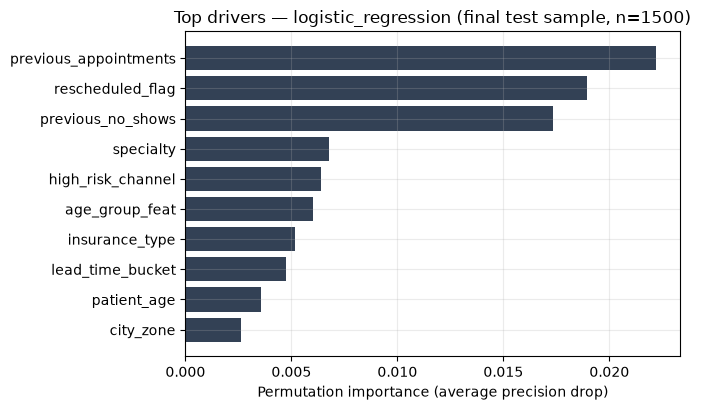

In [13]:
rng = np.random.default_rng(SEED)
sample_n = min(1500, len(X_test))
sample_idx = rng.choice(len(X_test), size=sample_n, replace=False)

perm = permutation_importance(
    fitted[selected], X_test.iloc[sample_idx], y_test[sample_idx],
    n_repeats=8, random_state=SEED, scoring="average_precision", n_jobs=-1,
)
order = np.argsort(perm.importances_mean)[::-1][:10]
perm_df = pd.DataFrame({
    "feature": [FEATURE_COLUMNS[i] for i in order],
    "importance_mean": perm.importances_mean[order],
}).iloc[::-1]

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.barh(perm_df["feature"], perm_df["importance_mean"], color="#334155")
ax.set_xlabel("Permutation importance (average precision drop)")
ax.set_title(f"Top drivers — {selected} (final test sample, n={sample_n})")
fig.tight_layout()
plt.show()

## 9. Concordance check vs. the published Evidence Pack manifest

Since this notebook re-derives the model from raw public data (rather than
loading the frozen `.joblib`), this section confirms the reproduction lines up
with `portfolio_manifest.json` in this same folder — same split, same selected
model and threshold, same headline metrics.

In [14]:
manifest = json.loads(Path("portfolio_manifest.json").read_text(encoding="utf-8"))

def _cmp(name, nb_val, mf_val):
    match = "OK" if str(nb_val) == str(mf_val) else "DIFF"
    print(f"{name:28s} notebook={nb_val!s:<14} manifest={mf_val!s:<14} [{match}]")

print("--- split ---")
_cmp("train_rows", split_meta["train_rows"], manifest["split"]["train_rows"])
_cmp("validation_rows", split_meta["validation_rows"], manifest["split"]["validation_rows"])
_cmp("test_rows", split_meta["test_rows"], manifest["split"]["test_rows"])
_cmp("validation_cutoff_date", split_meta["validation_cutoff_date"], manifest["split"]["validation_cutoff_date"])
_cmp("test_cutoff_date", split_meta["test_cutoff_date"], manifest["split"]["test_cutoff_date"])

print("\n--- model & threshold ---")
_cmp("selected_model", selected, manifest["selected_model"])
_cmp("threshold (4dp)", round(selected_threshold, 4), round(manifest["threshold"], 4))

print("\n--- metrics (4dp) ---")
_cmp("val_roc_auc", round(val_ranking["roc_auc"], 4), round(manifest["validation_metrics"]["ranking"]["roc_auc"], 4))
_cmp("val_average_precision", round(val_ranking["average_precision"], 4), round(manifest["validation_metrics"]["ranking"]["average_precision"], 4))
_cmp("test_roc_auc", round(test_ranking["roc_auc"], 4), round(manifest["final_test_metrics"]["ranking"]["roc_auc"], 4))
_cmp("test_average_precision", round(test_ranking["average_precision"], 4), round(manifest["final_test_metrics"]["ranking"]["average_precision"], 4))
_cmp("test_precision_at_thr", round(test_at_thr["precision"], 4), round(manifest["final_test_metrics"]["at_selected_threshold"]["precision"], 4))
_cmp("test_recall_at_thr", round(test_at_thr["recall"], 4), round(manifest["final_test_metrics"]["at_selected_threshold"]["recall"], 4))
_cmp("test_f1_at_thr", round(test_at_thr["f1"], 4), round(manifest["final_test_metrics"]["at_selected_threshold"]["f1"], 4))

--- split ---
train_rows                   notebook=6809           manifest=6809           [OK]
validation_rows              notebook=1580           manifest=1580           [OK]
test_rows                    notebook=2107           manifest=2107           [OK]
validation_cutoff_date       notebook=2024-08-16     manifest=2024-08-16     [OK]
test_cutoff_date             notebook=2024-12-31     manifest=2024-12-31     [OK]

--- model & threshold ---
selected_model               notebook=logistic_regression manifest=logistic_regression [OK]
threshold (4dp)              notebook=0.4114         manifest=0.4114         [OK]

--- metrics (4dp) ---
val_roc_auc                  notebook=0.6005         manifest=0.6005         [OK]
val_average_precision        notebook=0.1909         manifest=0.1909         [OK]
test_roc_auc                 notebook=0.6052         manifest=0.6052         [OK]
test_average_precision       notebook=0.1776         manifest=0.1776         [OK]
test_precision_at_thr   

## 10. Conclusion & limitations

**Conclusion.** On this synthetic clinic, no-show risk carries a modest but
usable ranking signal at booking time — driven mainly by lead time, prior
no-show history, and booking channel. Logistic Regression is preferred for its
operational interpretability; its scores are useful to **prioritize
confirmation outreach**, not to gate access to care.

**Limitations**

- Fully synthetic operational data — real-world calibration and effect sizes
  will differ.
- Moderate predictive signal (ROC AUC ≈ 0.60); scores rank relative risk, they
  are **not well-calibrated probabilities**.
- One professional per specialty in this synthetic design.
- No clinical prediction, diagnosis, or causal claim — associations reflect the
  generator's intentional design, not real-world behavior.
- Not an automated decision system: scores should inform reminder
  prioritization only, never deny scheduling or clinical access.

**Reproduce.** This notebook only needs `no_show_dataset.csv` (and, for the
concordance check, `portfolio_manifest.json`) in the same folder — no other
files from the Paradigm repository are required.